# Model 2 - Fixed service batch sizes, $b_I\in\{2,3,4\}$ (detailed diagrams)

## Load libraries

In [1]:
import matplotlib.pyplot as plt

import libs.tools as tools
import libs.QueueApprox as QueueApprox

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
# Number of operators needed in bS=1 case
c_needed = 16

data = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed" and rec["b_min"] == c_needed and isinstance(rec["bI"], int))
tools.load_statistics(data)

### Find results record with same parameters but other batch size

In [3]:
def find_same_with_other_b(base_rec, bI):
    for rec in data:
        if rec["mode"] != base_rec["mode"] or rec["S"] != base_rec["S"] or rec["model_rho"] != base_rec["model_rho"] or rec["model_CV[S]"] != base_rec["model_CV[S]"] or rec["b_min"] != base_rec["b_min"] or rec["b_max"] != base_rec["b_max"]:
            continue
        if rec["bI"] == bI:
            return rec
    raise ValueError("Record not found")

### Calculate E[W] increasement relative to b=1 case

In [4]:
for rec in data:
    if rec["b_max"] == 1:
        rec["E[W]rel"] = 1
    else:
        base = find_same_with_other_b(rec, 1)
        rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

## Plot results

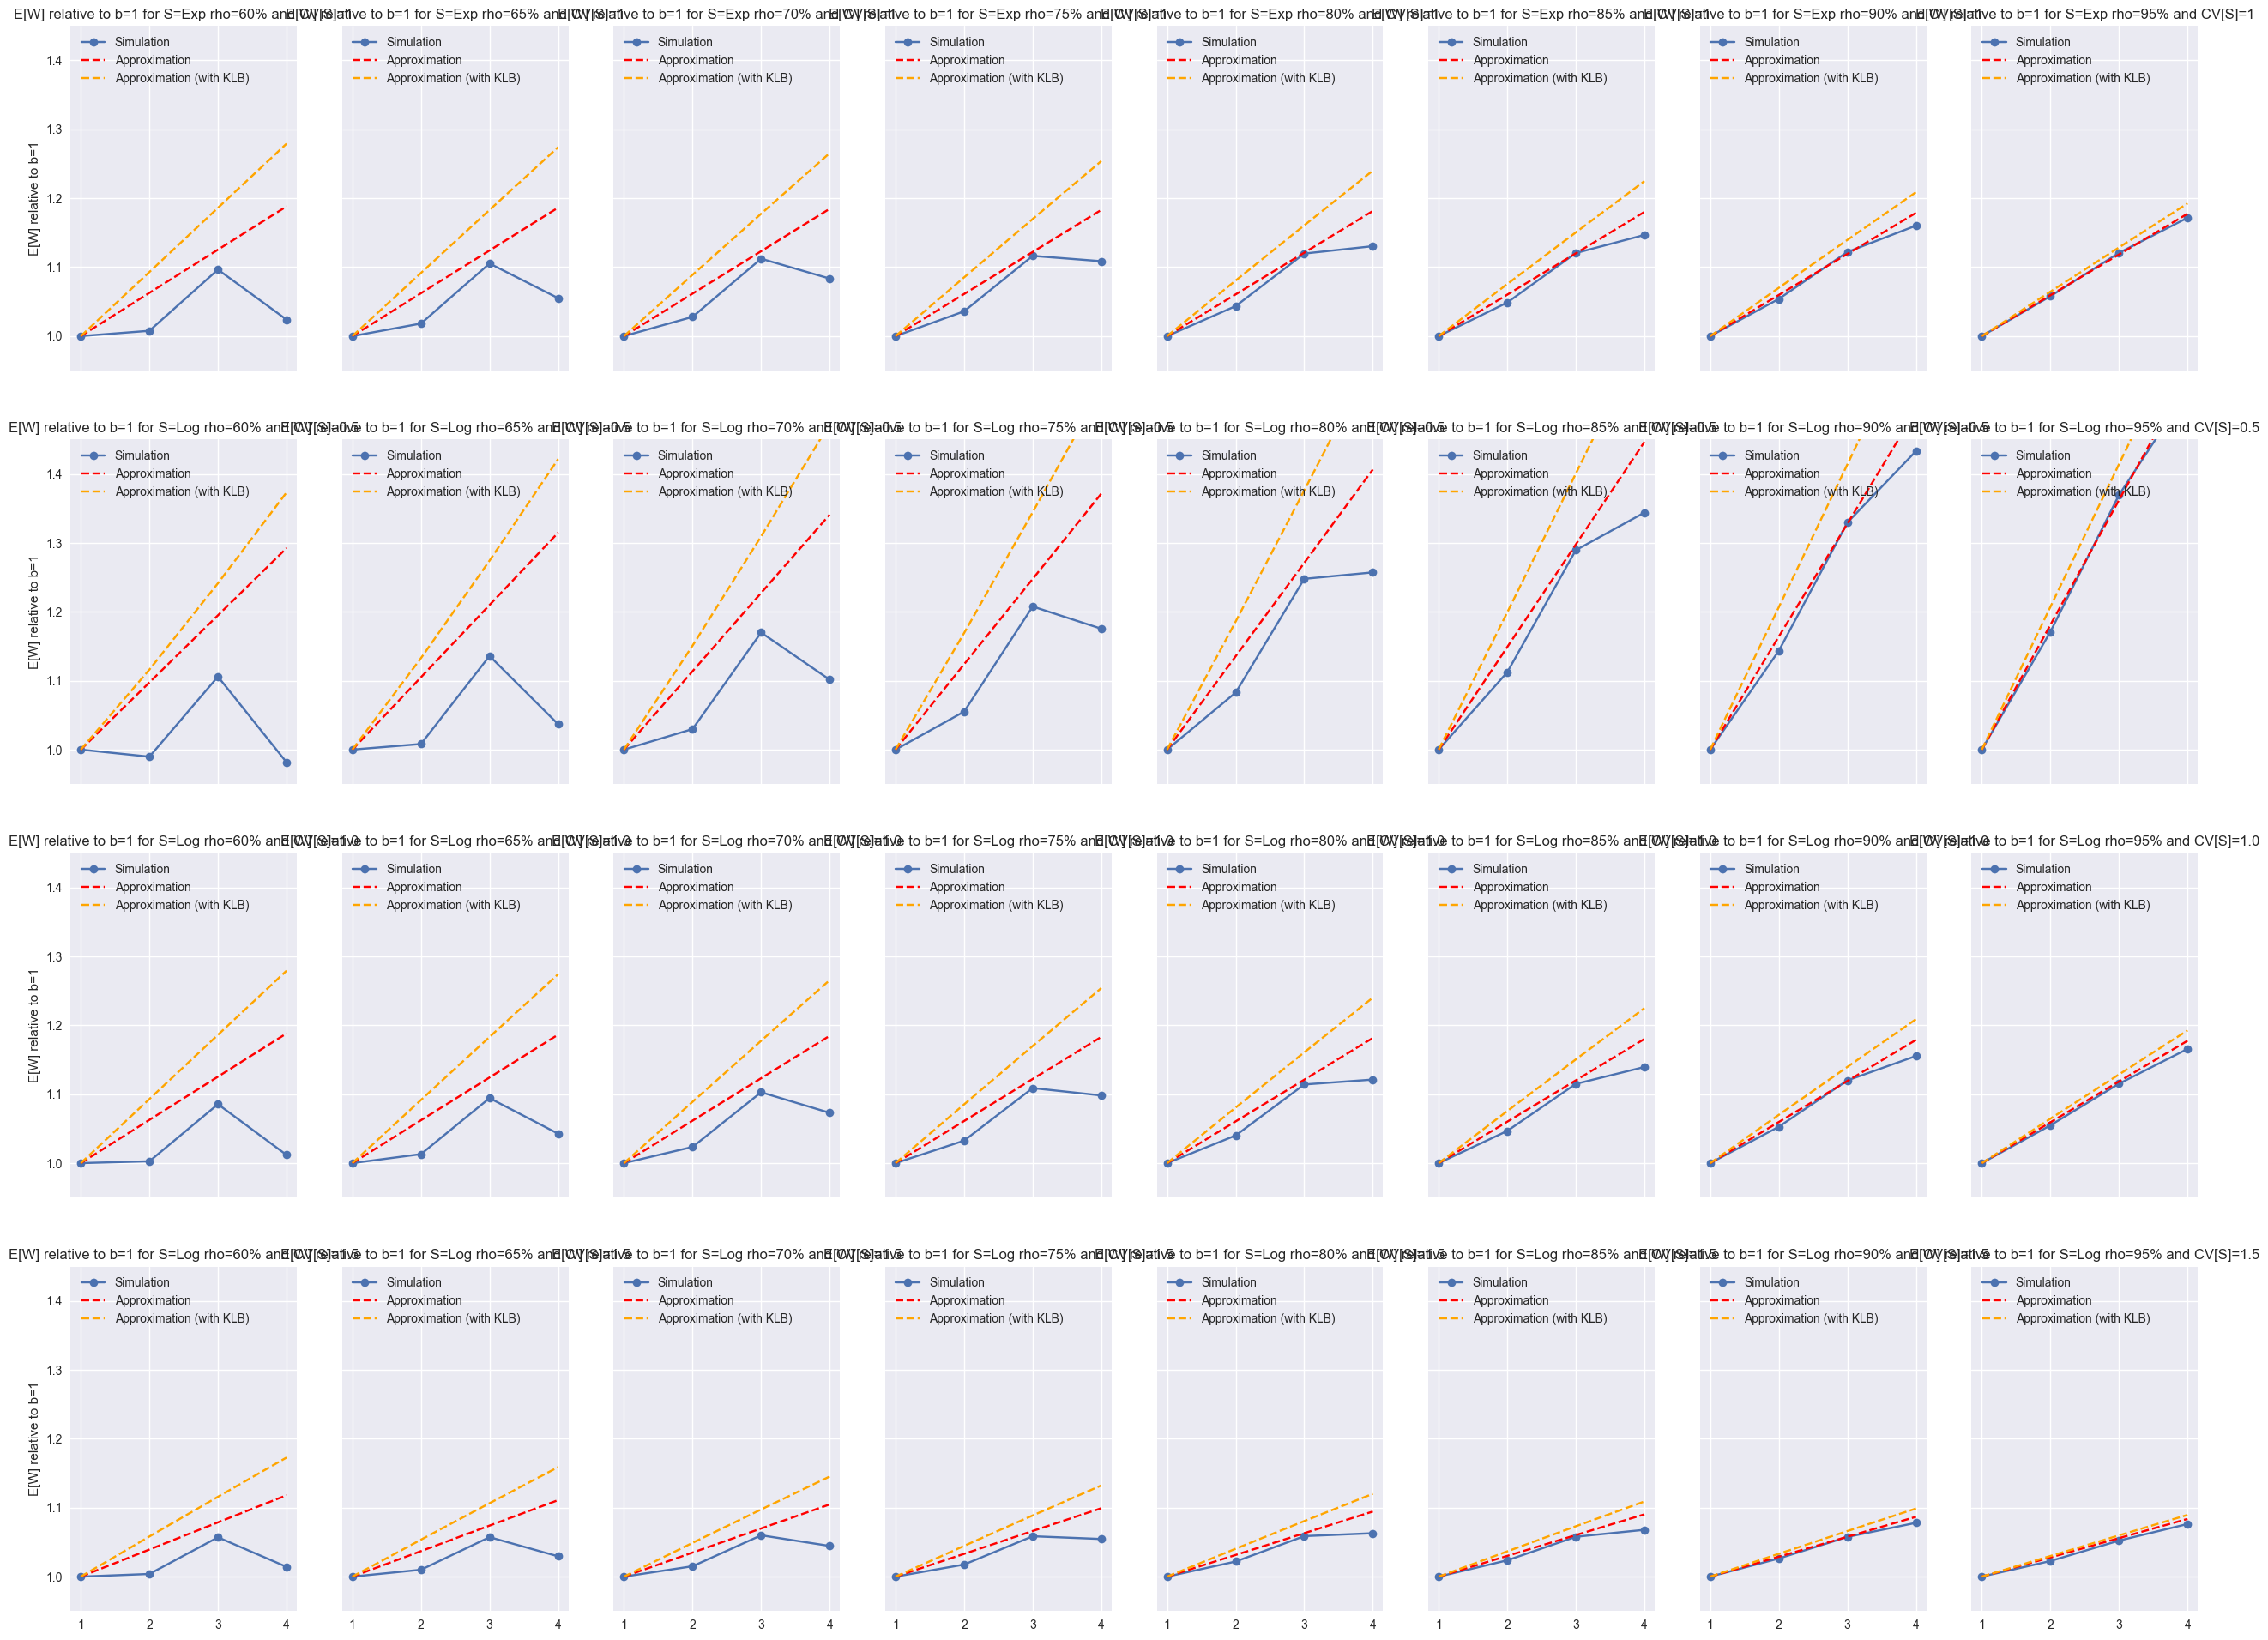

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.6 + j * 0.05
        plot_sim_data = []
        plot_approx1_data = []
        plot_approx2_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            bI = rec["bI"]
            name = rec["name_short"]
            plot_sim_data.append({"bI": bI, "name": name, "E[W]": rec["E[W]rel"]})
            plot_approx1_data.append({"bI": bI, "name": name, "E[W]": QueueApprox.EW_approx(1 / 100 / rec["bI"], 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], 1, rec["bI"], c_needed) / QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], 1, 1, c_needed)})
            plot_approx2_data.append({"bI": bI, "name": name, "E[W]": QueueApprox.EW_approx(1 / 100 / rec["bI"], 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], 1, rec["bI"], c_needed, True) / QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], 1, 1, c_needed, True)})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["bI"])
        plot_approx1_data = sorted(plot_approx1_data, key=lambda rec: rec["bI"])
        plot_approx2_data = sorted(plot_approx2_data, key=lambda rec: rec["bI"])

        x = [rec["bI"] for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]
        y_approx1 = [rec["E[W]"] for rec in plot_approx1_data]
        y_approx2 = [rec["E[W]"] for rec in plot_approx2_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o', label="Simulation")
        ax1.plot(x, y_approx1, linestyle='--', color='red', label="Approximation")
        ax1.plot(x, y_approx2, linestyle='--', color='orange', label="Approximation (with KLB)")
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("E[W] relative to b=1")
        ax1.set_ylim(0.95, 1.45)
        ax1.legend(loc=2)

        ax1.set_title(f"E[W] relative to b=1 for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model02-EWrel-details.png", format="png", bbox_inches='tight', pad_inches=0)

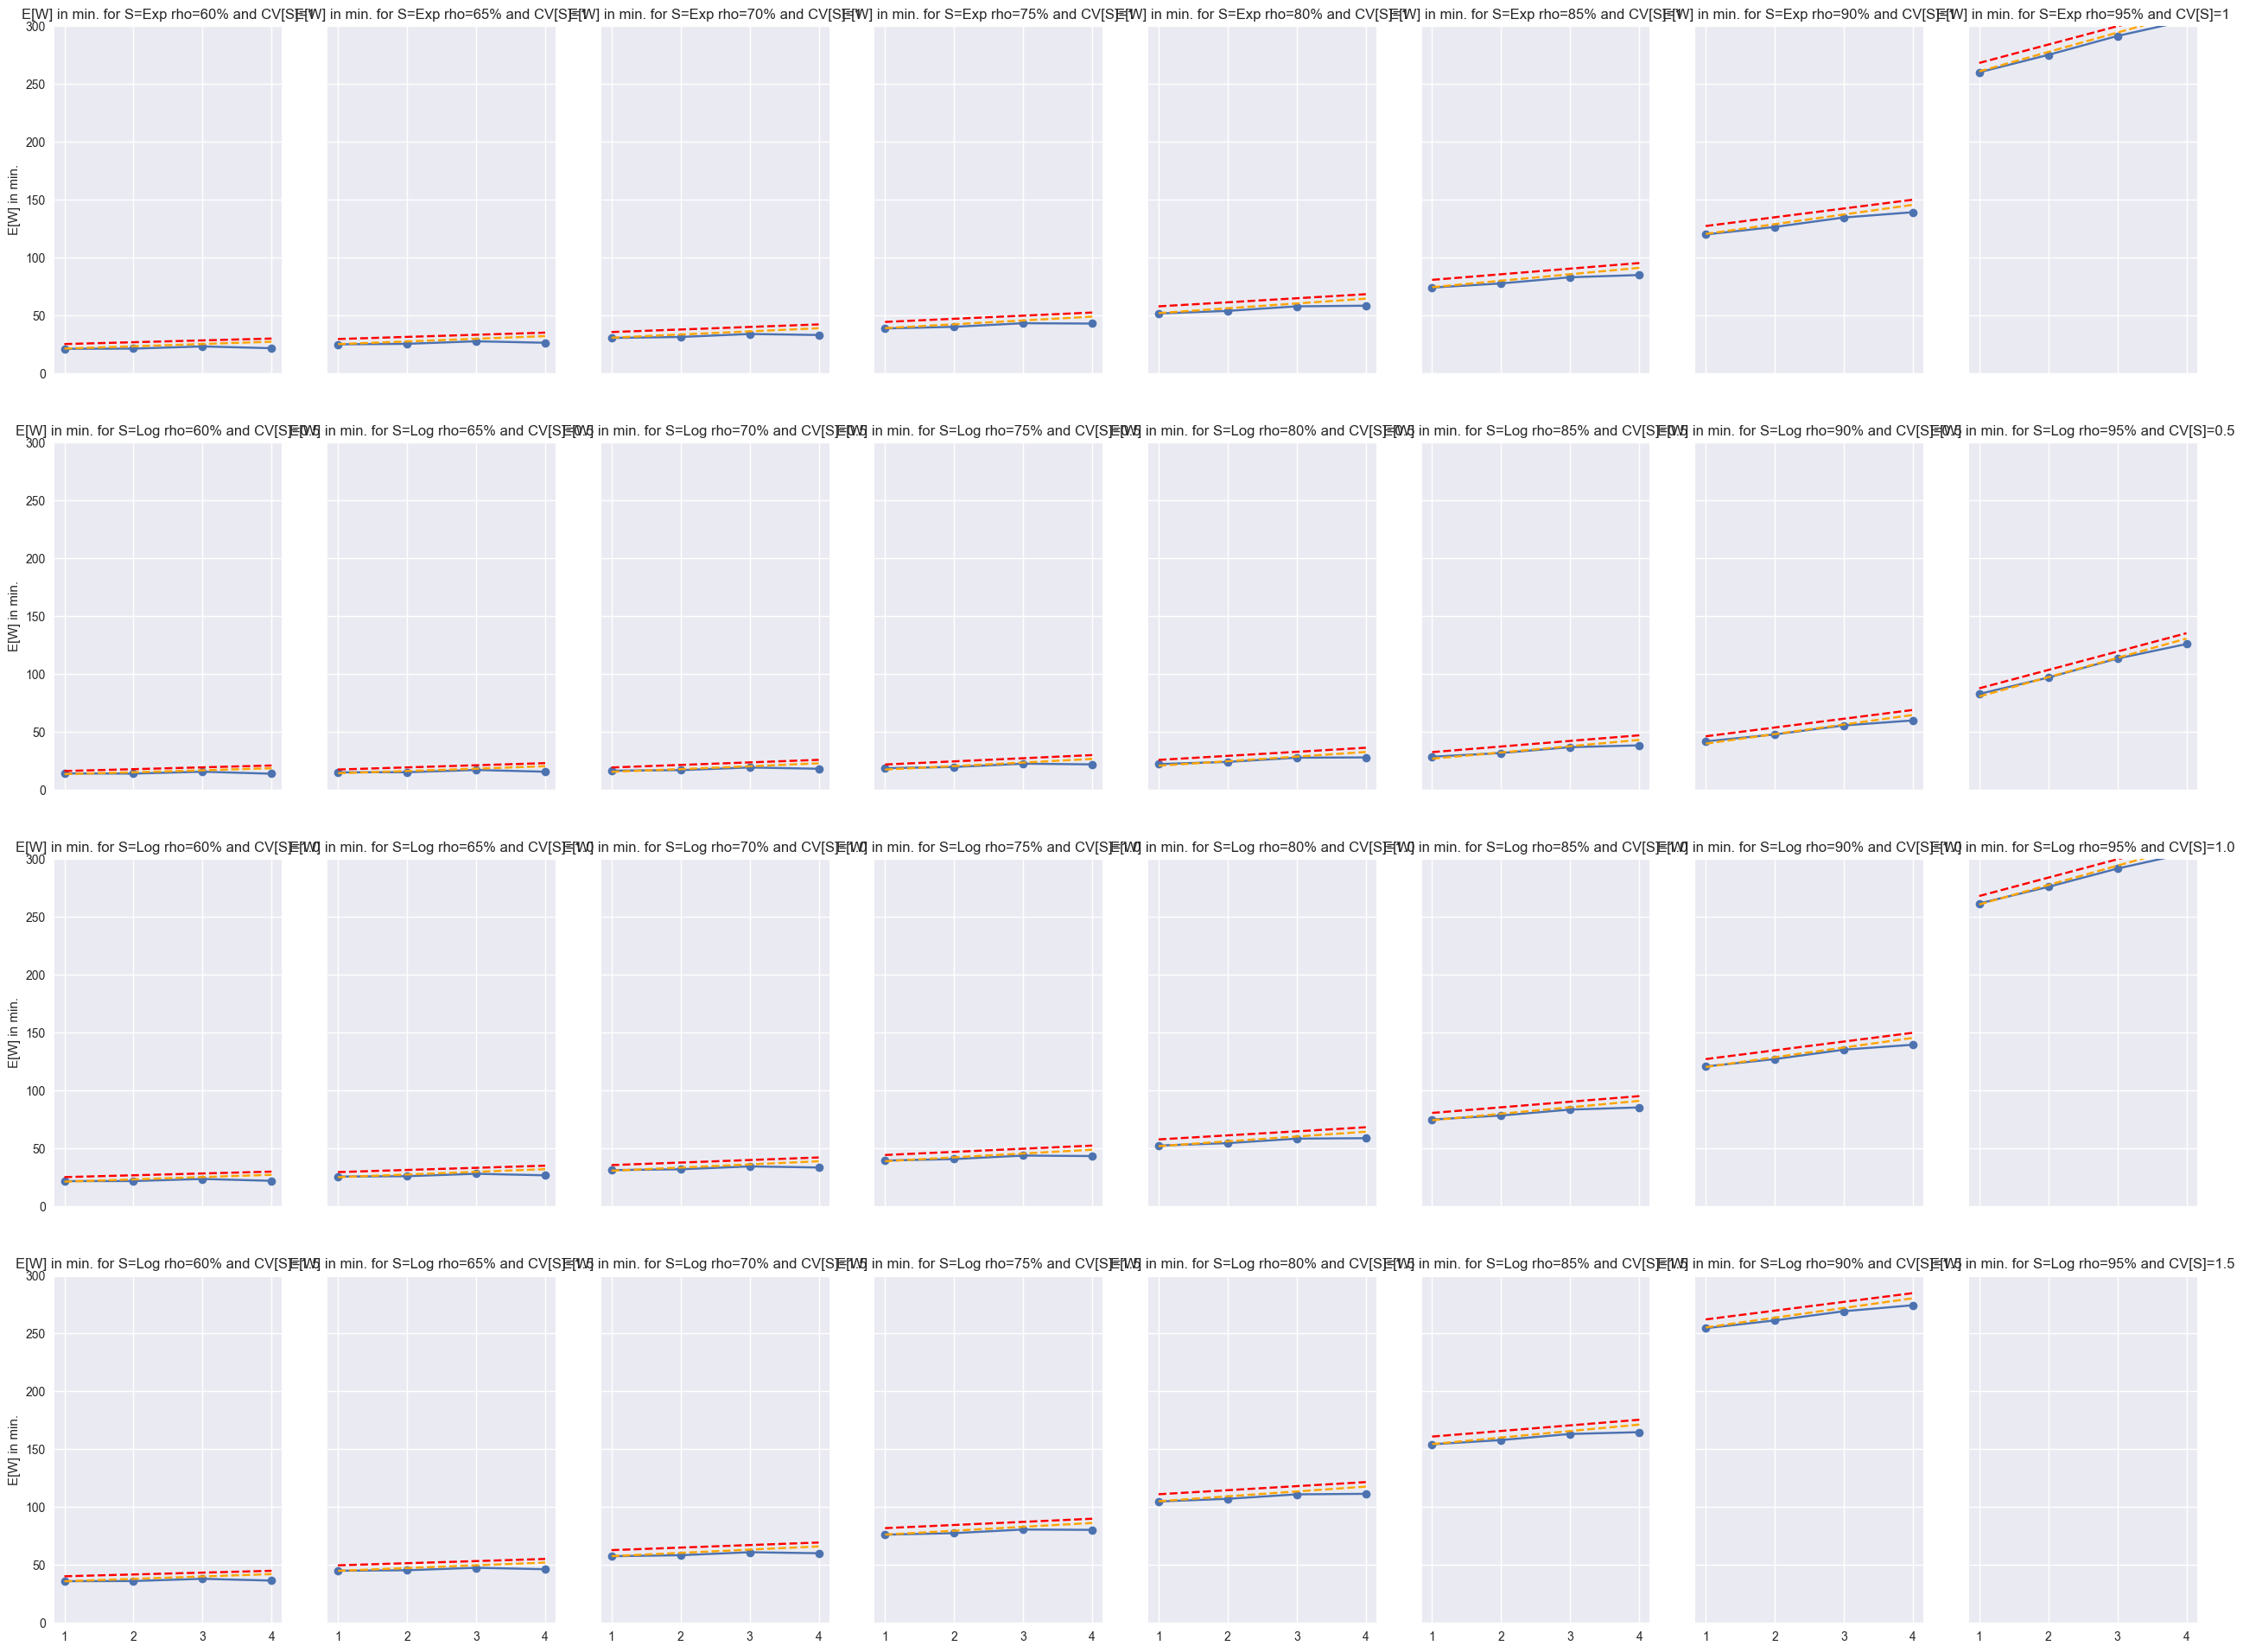

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.6 + j * 0.05
        plot_sim_data = []
        plot_approx1_data = []
        plot_approx2_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            bI = rec["bI"]
            name = rec["name_short"]
            plot_sim_data.append({"bI": bI, "name": name, "E[W]": rec["E[W]"]/60})
            plot_approx1_data.append({"bI": bI, "name": name, "E[W]": QueueApprox.EW_approx(1 / 100 / rec["bI"], 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], 1, rec["bI"], c_needed)/60})
            plot_approx2_data.append({"bI": bI, "name": name, "E[W]": QueueApprox.EW_approx(1 / 100 / rec["bI"], 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], 1, rec["bI"], c_needed, True)/60})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["bI"])
        plot_approx1_data = sorted(plot_approx1_data, key=lambda rec: rec["bI"])
        plot_approx2_data = sorted(plot_approx2_data, key=lambda rec: rec["bI"])

        x = [rec["bI"] for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]
        y_approx1 = [rec["E[W]"] for rec in plot_approx1_data]
        y_approx2 = [rec["E[W]"] for rec in plot_approx2_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o', label="Simulation")
        ax1.plot(x, y_approx1, linestyle='--', color='red', label="Approximation")
        ax1.plot(x, y_approx2, linestyle='--', color='orange', label="Approximation (with KLB)")
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("E[W] in min.")
        ax1.set_ylim(0, 300)

        ax1.set_title(f"E[W] in min. for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model02-EW-details.png", format="png", bbox_inches='tight', pad_inches=0)